In [1]:
import ojas_feb0126_find_best_run as fbr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
root_path = "/mnt/home/donti-group-shared/ojas/pfdelta/runs/gen_feb0126"

cases = ["case14", "case30", "case57", "case118", "case500"]
combined_cases = ["case14_30_118", "case30_57_118", "case30_57_500", "case57_118_500"]
tasks = ["task31", "task32", "task33", "task34"]
models = ["graphconv", "powerflownet"]
error_key = "PBL Mean"

In [3]:
results = {}

def add_result(best_runs, task, model, case):
    if results.get(task) is None:
        results[task] = {}
    if results[task].get(model) is None:
        results[task][model] = {}
        
    results[task][model][case] = best_runs

In [4]:
for model in models:
    # print("---------------TASK 1")
    for task in [tasks[0]]:
        for case in cases:
            folder = f"{root_path}/{task}/{model}/{case}"
            best_runs = fbr.find_best_run(folder, error_key)
            add_result(best_runs, task, model, case)

    # print("---------------TASK 2 AND 3")
    for task in [tasks[1], tasks[2]]:
        case = "case14_30_57" if task == tasks[1] else "case118_500"
        folder = f"{root_path}/{task}/{model}/"
        best_runs = fbr.find_best_run(folder, error_key)
        add_result(best_runs, task, model, case)

    for task in [tasks[3]]:
        for case in combined_cases:
            folder = f"{root_path}/{task}/{model}/{case}"
            best_runs = fbr.find_best_run(folder, error_key)
            add_result(best_runs, task, model, case)

/mnt/home/donti-group-shared/ojas/pfdelta/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [5]:
ROWS = ["14", "30", "57", "118", "500", "14_30_57", "118_500", "14_30_118", "30_57_118", "30_57_500", "57_118_500"]
COLS = ROWS.copy()[:5]

row_to_cols = {}

for row in ROWS:
    row_to_cols[row] = [COLS]
    
row_idx = {r: i for i, r in enumerate(ROWS)}
col_idx = {c: j for j, c in enumerate(COLS)}

In [6]:
def get_row_col(train_case, test_case):
    if test_case.startswith("case"):
        test_case = test_case[4:]
    if train_case.startswith("case"):
        train_case = train_case[4:]
    return [row_idx[train_case], col_idx[test_case]]

In [7]:
graphconv_means = np.full((len(ROWS), len(COLS)), np.nan, dtype=float)
graphconv_stds = np.full((len(ROWS), len(COLS)), np.nan, dtype=float)
powerflownet_means = np.full((len(ROWS), len(COLS)), np.nan, dtype=float)
powerflownet_stds = np.full((len(ROWS), len(COLS)), np.nan, dtype=float)

In [8]:
for task, task_values in results.items():
    for model, model_values in task_values.items():
        # print(f"Task {task}: {model_values.items()}")
        for train_case, train_values in model_values.items():
            # print(train_values)
            summaries = train_values[4]

            # print(summaries)

            if summaries is None:
                continue

            mean_err_per_test_case_per_seed = {
                "case14": [],
                "case30": [],
                "case57": [],
                "case118": [],
                "case500": [],
            }

            # go through all of the seeds
            # for each seed, get the summary
            for summary in summaries:
                if summary is None:
                    [mean_err_per_test_case_per_seed[i].append(np.nan) for i in cases]
                    continue

                val = summary["val"]
                
                print(val)
                # print(cases)

                # go through all of the validation sets
                # skip the first one (its a duplicate of the second one for config reasons)
                start_index = 1
                # mistake in this config where theres an extra duplicate val, so skip the first two instead of just the first one
                if (task == "task34") and (model == "graphconv"):
                    start_index = 2
                    
                # take the pbl mean, put it into the appropriate spot in the list
                # depending on the test_case
                # we shoud have one entry per test case per seed
                for i in range(start_index, len(val)):
                    print(task)
                    print(model)
                    print(start_index)
                    print(len(val))
                    print(i)
                    print(cases)
                    test_case = cases[i - start_index]
                    val_dict = val[i]
                    err = val_dict[error_key]

                    mean_err_per_test_case_per_seed[test_case].append(err)

            # print("Processing:", task, model, train_case)
            # print(mean_err_per_test_case_per_seed)

            for test_case in mean_err_per_test_case_per_seed.keys():
                # calculate mean and std for the err for each test_case
                errs = mean_err_per_test_case_per_seed[test_case]
                mean_err = np.mean(errs)
                std_err = np.std(errs)
                
                # print(f"\t{train_case}, {test_case}", end=": ")

                # these should be the same
                # best_err_mean = train_values[2]
                # best_err_std = train_values[3]
                # print("this case best err mean std: ", best_err_mean, best_err_std)
                # print("computed case mean std: ", mean_err, std_err)
                
                r, c = get_row_col(train_case, test_case)
                # print(r, c)
                # print(mean_err)

                if model == "graphconv":
                    graphconv_means[r, c] = mean_err
                    graphconv_stds[r, c] = std_err
                elif model == "powerflownet":
                    powerflownet_means[r, c] = mean_err
                    powerflownet_stds[r, c] = std_err

[{'Masked MSE': 0.11289699375629425, 'Masked MSE, reg.': 0.11344957531375044, 'MSELoss': 0.038000718241228776, 'PBL Mean': 0.24143992487122032, 'PBL Max': 3.02486246473649, 'PBL L2': 1.205964561069713}, {'Masked MSE': 0.11289699375629425, 'Masked MSE, reg.': 0.11344957531375044, 'MSELoss': 0.03800071810974794, 'PBL Mean': 0.24143992522183585, 'PBL Max': 3.02486246473649, 'PBL L2': 1.2059645631734062}, {'Masked MSE': 0.9719689768903396, 'Masked MSE, reg.': 1.1201611413675197, 'MSELoss': 0.4227844224256628, 'PBL Mean': 1.1283092344508452, 'PBL Max': 10.303076082117418, 'PBL L2': 9.4320177414838}, {'Masked MSE': 5.736920928955078, 'Masked MSE, reg.': 6.428180879705092, 'MSELoss': 2.373146951899809, 'PBL Mean': 6.037014703189626, 'PBL Max': 82.79916767793543, 'PBL L2': 77.8700901704676}, {'Masked MSE': 83.27511381261489, 'Masked MSE, reg.': 125.32391186882468, 'MSELoss': 55.7909028894761, 'PBL Mean': 21.758265596277575, 'PBL Max': 2071.1322021484375, 'PBL L2': 495.3709142348346}, {'Masked 

In [9]:
def plot_grouped_bar_chart(means: np.ndarray, stds: np.ndarray, model_name: str):
    n_test, n_train = means.shape
    x = np.arange(n_test)  # group positions
    bar_width = 0.8 / n_train  # width of each bar

    fig, ax = plt.subplots(figsize=(14, 5.5))
    # "Set3" or "tab20"
    cmap = plt.colormaps["tab20"]

    for i in range(n_train):
        offset = (i - n_train / 2) * bar_width + bar_width / 2

        # length n_test
        y = means[:, i]
        yerr = stds[:, i]

        # If NaNs appear in means or stds, bar() will quietly skip drawing those bars
        ax.bar(
            x + offset,
            y,
            width=bar_width,
            yerr=yerr,
            label=f"Case {ROWS[i]}",
            capsize=3,
            linewidth=0.8,
            edgecolor="black",
            alpha=0.95,
            color=cmap(i),
            error_kw=dict(elinewidth=1, capsize=3, capthick=1),
        )

    # --- cosmetics ---

    title_size = 20
    label_size = 16
    tick_size = 14
    legend_title_size = 14
    legend_text_size = 12

    # titles & labels
    ax.set_title(
        f"{model_name}: Performance on different test cases across different train cases",
        pad=10,
        fontsize=title_size,
    )
    ax.set_ylabel("Mean PBL (+/- 1 SD) (log)", fontsize=label_size)
    ax.set_xlabel("Test Case", fontsize=label_size)

    # x ticks
    ax.set_xticks(x, [f"Case {COLS[i]}" for i in range(n_test)], fontsize=tick_size)

    # log y with helpful grid
    ax.set_yscale("log")
    
    ax.grid(True, which="both", axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

    # de-clutter spines
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(
        # loc="upper right",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Trained On",
        title_fontsize=legend_title_size,
        fontsize=legend_text_size,
    )
    
    # catch error in case there is no data
    # and log doesn't woork
    try:
        fig.tight_layout()
    except ValueError:
        ax.set_yscale("linear")
    plt.show()

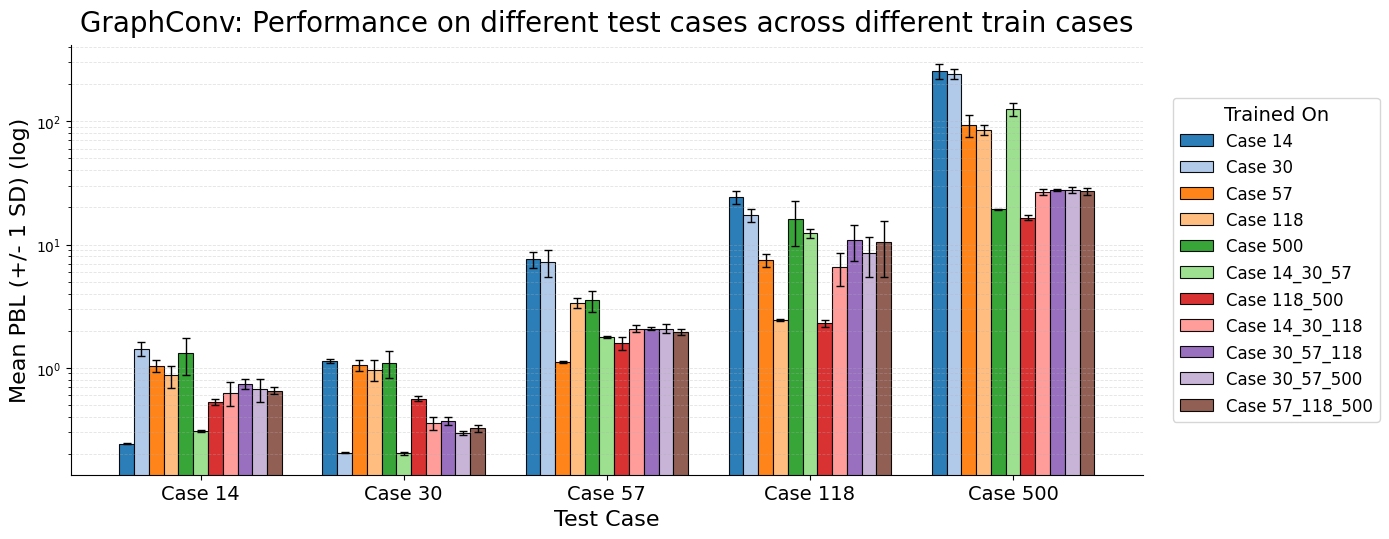

In [10]:
means = graphconv_means.T
stds = graphconv_stds.T

plot_grouped_bar_chart(means, stds, "GraphConv")

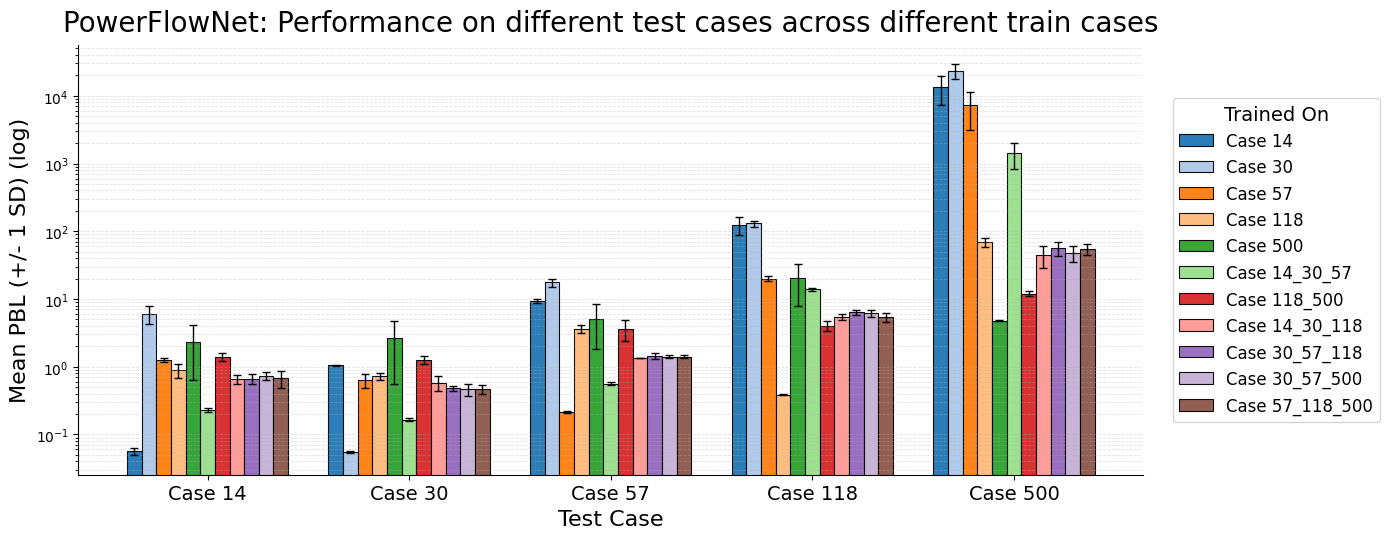

In [11]:
means = powerflownet_means.T
stds = powerflownet_stds.T

plot_grouped_bar_chart(means, stds, "PowerFlowNet")

## Interactive visualization (Plotly)
Hover any bar to see exactly which train-case key (grid-size case) it corresponds to.


In [12]:
try:
    import plotly.graph_objects as go
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("plotly is required for this interactive chart. Run `%pip install plotly` and re-run this cell.") from exc


def plot_grouped_bar_chart_interactive(means: np.ndarray, stds: np.ndarray, model_name: str):
    n_test, n_train = means.shape
    x_labels = [f"Case {COLS[i]}" for i in range(n_test)]
    cmap = plt.colormaps["tab20"]

    fig = go.Figure()

    for i in range(n_train):
        y = means[:, i]
        yerr = stds[:, i]
        train_case_label = f"Case {ROWS[i]}"

        r, g, b, a = cmap(i)
        bar_color = f"rgba({int(r * 255)}, {int(g * 255)}, {int(b * 255)}, {a:.3f})"

        customdata = np.array([[train_case_label, yerr[j]] for j in range(n_test)], dtype=object)

        fig.add_bar(
            x=x_labels,
            y=y,
            name=train_case_label,
            marker_color=bar_color,
            error_y=dict(type="data", array=yerr, visible=True, thickness=1.0, width=3),
            customdata=customdata,
            hovertemplate=(
                "Trained on: %{customdata[0]}<br>"
                "Mean PBL: %{y:.4g}<br>"
                "Std Dev: %{customdata[1]:.4g}<extra></extra>"
            ),
        )

    fig.update_layout(
        title=f"{model_name}: Performance on different test cases across different train cases",
        xaxis_title="Test Case",
        yaxis_title="Mean PBL (+/- 1 SD) (log)",
        barmode="group",
        legend_title="Trained On",
        template="plotly_white",
        width=1400,
        height=550,
    )

    fig.update_yaxes(type="log", showgrid=True, gridcolor="rgba(0, 0, 0, 0.15)")
    fig.show()
    return fig


In [13]:
means = graphconv_means.T
stds = graphconv_stds.T

fig_graphconv = plot_grouped_bar_chart_interactive(means, stds, "GraphConv")


In [14]:
means = powerflownet_means.T
stds = powerflownet_stds.T

fig_powerflownet = plot_grouped_bar_chart_interactive(means, stds, "PowerFlowNet")


## Export interactive HTML for Slack sharing
This writes self-contained HTML files (interactive in any browser) plus a small index page.


In [15]:
from pathlib import Path

EXPORT_DIR = Path("interactive_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

graphconv_path = EXPORT_DIR / "graphconv_interactive.html"
powerflownet_path = EXPORT_DIR / "powerflownet_interactive.html"
index_path = EXPORT_DIR / "index.html"

fig_graphconv.write_html(graphconv_path, full_html=True, include_plotlyjs=True)
fig_powerflownet.write_html(powerflownet_path, full_html=True, include_plotlyjs=True)

index_html = f"""<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1" />
  <title>PFDelta Interactive Charts</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 2rem; line-height: 1.5; }}
    h1 {{ margin-bottom: 0.5rem; }}
    ul {{ padding-left: 1.2rem; }}
  </style>
</head>
<body>
  <h1>PFDelta Interactive Charts</h1>
  <p>Open one of the charts below:</p>
  <ul>
    <li><a href="{graphconv_path.name}">GraphConv interactive chart</a></li>
    <li><a href="{powerflownet_path.name}">PowerFlowNet interactive chart</a></li>
  </ul>
</body>
</html>
"""
index_path.write_text(index_html)

print(f"Wrote: {graphconv_path}")
print(f"Wrote: {powerflownet_path}")
print(f"Wrote: {index_path}")


Wrote: interactive_exports/graphconv_interactive.html
Wrote: interactive_exports/powerflownet_interactive.html
Wrote: interactive_exports/index.html


## Optional: auto-deploy export folder
Supports Netlify, Vercel, or Render deploy-hook trigger. Requires provider CLI/auth setup.


In [16]:
import json
import os
import re
import subprocess
import urllib.request
from pathlib import Path


def _run_cmd(cmd):
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        parts = [
            "Command failed:",
            " ".join(cmd),
            "",
            "stdout:",
            result.stdout,
            "",
            "stderr:",
            result.stderr,
        ]
        raise RuntimeError(chr(10).join(parts))
    return result.stdout.strip() or result.stderr.strip()


def deploy_site(provider, site_dir=EXPORT_DIR, netlify_site_id=None, vercel_project_name=None, render_deploy_hook_url=None):
    provider = provider.lower().strip()
    site_dir = Path(site_dir)
    if not site_dir.exists():
        raise FileNotFoundError(f"site_dir does not exist: {site_dir}")

    if provider == "netlify":
        cmd = ["npx", "netlify-cli", "deploy", "--dir", str(site_dir), "--prod", "--json"]
        if netlify_site_id:
            cmd.extend(["--site", netlify_site_id])
        stdout = _run_cmd(cmd)

        deploy_url = None
        for line in reversed(stdout.splitlines()):
            line = line.strip()
            if not line:
                continue
            try:
                payload = json.loads(line)
                deploy_url = payload.get("deploy_url") or payload.get("url")
                if deploy_url:
                    break
            except json.JSONDecodeError:
                continue

        if not deploy_url:
            urls = re.findall(r"https?://[^\s]+", stdout)
            deploy_url = urls[-1] if urls else None

        if deploy_url:
            print(f"Netlify URL: {deploy_url}")
        else:
            print("Netlify deploy completed, but URL parsing failed. Check command output manually.")
        return deploy_url

    if provider == "vercel":
        cmd = ["npx", "vercel", str(site_dir), "--prod", "--yes"]
        token = os.getenv("VERCEL_TOKEN")
        if token:
            cmd.extend(["--token", token])
        if vercel_project_name:
            cmd.extend(["--name", vercel_project_name])

        stdout = _run_cmd(cmd)
        urls = re.findall(r"https?://[^\s]+", stdout)
        deploy_url = urls[-1] if urls else None
        if deploy_url:
            print(f"Vercel URL: {deploy_url}")
        else:
            print("Vercel deploy completed, but URL parsing failed. Check command output manually.")
        return deploy_url

    if provider == "render":
        if not render_deploy_hook_url:
            raise ValueError("For Render, pass render_deploy_hook_url from your Render Static Site settings.")

        req = urllib.request.Request(render_deploy_hook_url, method="POST")
        with urllib.request.urlopen(req) as resp:
            body = resp.read().decode("utf-8", errors="replace")
            print(f"Render deploy hook response code: {resp.status}")
            print(body[:500])
        print("Render deploy triggered. It will publish whatever your Render service builds from its linked repo.")
        return None

    raise ValueError("provider must be one of: 'netlify', 'vercel', 'render'")


### Interactive HTML Deploy Automation
------
- Interactive export notebook: `notebooks/ojas_feb0126_test_case_viz_interactive.ipynb`
- Generated static site directory: `notebooks/interactive_exports`

From the repository root:

```bash
# 1) (Optional) regenerate HTML files from the notebook
bash scripts/interactive_exports/generate_interactive_exports.sh

# 2) Deploy the generated site to Vercel
bash scripts/interactive_exports/deploy_interactive_exports.sh notebooks/interactive_exports